In [1]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.callbacks import ModelCheckpoint
# import warnings
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions import getModel, kCrossVal, transfBestparam, import_data
from time import perf_counter
import pandas
import pickle
import os

seed = 7
np.random.seed(seed)

c:\Users\Giacomo\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [3]:
#file_path_LF = "../DATA/reaction_diffusion_LF_28_d1.mat"
#(reaction_LF_test, U_LF_test) = import_data(file_path_LF)
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

MemoryError: Unable to allocate 2.98 GiB for an array with shape (50, 801, 100, 100) and data type float64

In [ ]:
# NORMALIZATION

reaction_max = np.max(reaction_HF_test)
reaction_min = np.min(reaction_HF_test)

#reaction_LF_test = (reaction_LF_test - reaction_min) / (
#    reaction_max - reaction_min
#)
reaction_HF_test = (reaction_HF_test - reaction_min) / (
    reaction_max - reaction_min
)

In [ ]:
# Output
# We consider the central value of U
#U_LF_test = U_LF_test[
#    :,
#    - 1,
#    12,12
#]

U_HF_test = U_HF_test[:, -1, 44,44]

U_h_max_test = np.max(U_HF_test)
U_h_min_test = np.min(U_HF_test)
#U_t_max_test = np.max(U_LF_test)
#U_t_min_test = np.min(U_LF_test)

#U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
U_HF_test = (U_HF_test - U_h_min_test) / (U_h_max_test - U_h_min_test)

#permutation = np.random.permutation(len(reaction_LF_test))
#Nlf = 20
#reaction_LF = reaction_LF_test[permutation][0:Nlf]
#U_LF = U_LF_test[permutation][0:Nlf]

permutation = np.random.permutation(len(reaction_HF_test))
n_HF = 15
reaction_HF = reaction_HF_test[permutation][0:n_HF]
U_HF = U_HF_test[permutation][0:n_HF]


# da aggiustare cicli

In [ ]:
NepoLF = 8000  # number of epochs for first NN: NN_LF
NepoLin = 1500
NepoHF = 3000  # number of epochs for second NN: NN_HF 
Nlf=30

U_LF_list = []
U_Lin_list = []
U_HF_list = []

#HF_data = [10]
#HF_data_str = [str(num) for num in HF_data]
r2_HF_df = pandas.DataFrame()  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame()  # dataframe which stores LF R^2
r2_Lin_df = pandas.DataFrame()
mse_HF_df = pandas.DataFrame()  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame()  # dataframe which stores LF MSE
mse_Lin_df = pandas.DataFrame()


********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0685211452749587
R^2: 0.45038456232463475
2/2 [==============================] - 0s 0s/step
Elapsed time:  24.3209446999972
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.1191995190378467
R^2: -0.05301056841749485

HF Model:
Test MSE: 0.10590699356582615
R^2: 0.06441582655438571
2/2 [==============================] - 0s 5ms/step


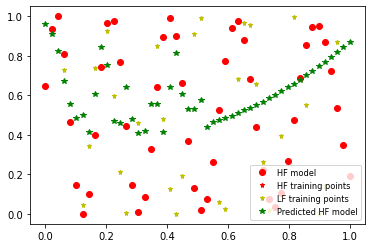

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.01076528251164725
R^2: 0.9134704013287839
2/2 [==============================] - 0s 3ms/step
Elapsed time:  28.239302200003294
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.12138284615081911
R^2: -0.072298117082372

HF Model:
Test MSE: 0.12868137916215397
R^2: -0.1367734812190291
2/2 [==============================] - 0s 5ms/step


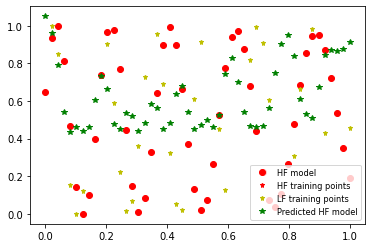

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.004929679599573533
R^2: 0.9613581997257326
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.796788699997705
2/2 [==============================] - 0s 16ms/step

Lin Model:
Test MSE: 0.1297139704263971
R^2: -0.14589540992210015

HF Model:
Test MSE: 0.2586714159103518
R^2: -1.285107665699842
2/2 [==============================] - 0s 0s/step


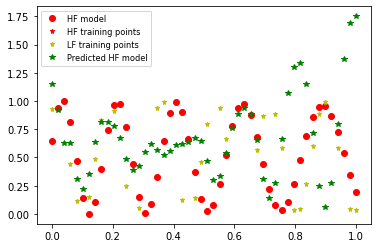

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.0004933213946286331
R^2: 0.9959395215220638
2/2 [==============================] - 0s 4ms/step
Elapsed time:  23.086685100002796
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.12132342320912608
R^2: -0.0717731738098295

HF Model:
Test MSE: 0.09903335477802805
R^2: 0.12513766792974979
2/2 [==============================] - 0s 16ms/step


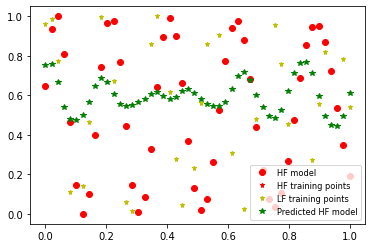

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.004597768113128823
R^2: 0.9631087827874285
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.821999799998594
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.12494503367107106
R^2: -0.10376654191988521

HF Model:
Test MSE: 0.1229615477540544
R^2: -0.08624439376203363
2/2 [==============================] - 0s 0s/step


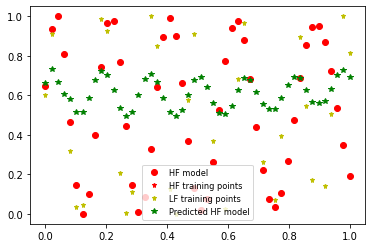

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.0030384328725534316
R^2: 0.973172338957273
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.778850899994723
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.006015662657641124
R^2: 0.9468575342781432

HF Model:
Test MSE: 0.00574922737253085
R^2: 0.9492112280957448
2/2 [==============================] - 0s 5ms/step


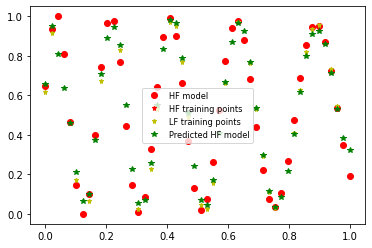

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 8.105669206376096e-06
R^2: 0.9999310605701183
2/2 [==============================] - 0s 0s/step
Elapsed time:  23.182673300005263
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.07319892673378321
R^2: 0.35335944247377027

HF Model:
Test MSE: 0.05965384980745782
R^2: 0.4730168812669584
2/2 [==============================] - 0s 4ms/step


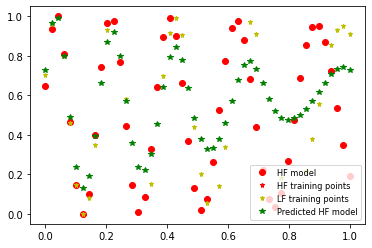

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.0003613367484495733
R^2: 0.9969441982296823
2/2 [==============================] - 0s 17ms/step
Elapsed time:  22.975183500006096
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.08116879982103306
R^2: 0.2829534487452585

HF Model:
Test MSE: 0.05978853554511831
R^2: 0.47182706518115203
2/2 [==============================] - 0s 0s/step


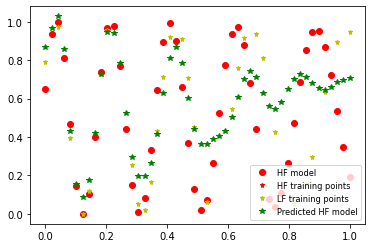

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.13049793672379592
R^2: -0.047484814201964154
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.68641110000317
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.1198801450683193
R^2: -0.05902323028905965

HF Model:
Test MSE: 0.12726695799133908
R^2: -0.12427846065951975
2/2 [==============================] - 0s 5ms/step


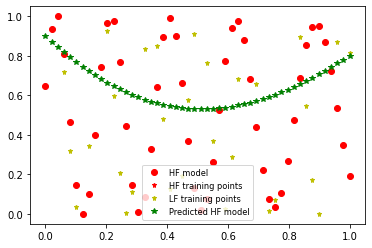

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 17ms/step

LF Model:
Test MSE: 0.00013518338237826526
R^2: 0.9988116960743643
2/2 [==============================] - 0s 0s/step
Elapsed time:  22.753294900001492
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.023120954640635717
R^2: 0.7957490954241123

HF Model:
Test MSE: 0.022560780018248794
R^2: 0.8006976875182249
2/2 [==============================] - 0s 7ms/step


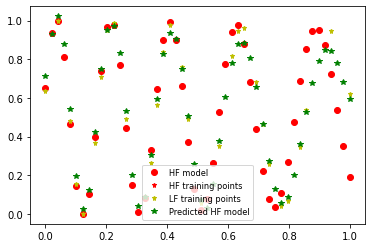

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.0015386331253066582
R^2: 0.9869372899497513
2/2 [==============================] - 0s 3ms/step
Elapsed time:  23.362218900001608
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.016853539156546173
R^2: 0.8511155498752775

HF Model:
Test MSE: 0.017140660417780937
R^2: 0.8485791157945195
2/2 [==============================] - 0s 3ms/step


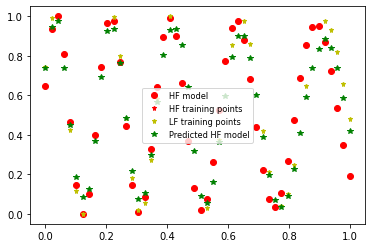

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.0027647520272655437
R^2: 0.9761154735349767
2/2 [==============================] - 0s 3ms/step
Elapsed time:  22.48713750000752
2/2 [==============================] - 0s 5ms/step

Lin Model:
Test MSE: 0.02014635410164308
R^2: 0.8220267669253295

HF Model:
Test MSE: 0.02017055706069815
R^2: 0.8218129575754456
2/2 [==============================] - 0s 2ms/step


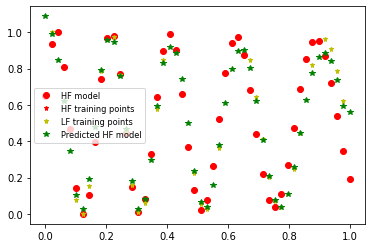

        10       28       46
0  0.12514  0.47183  0.82181
        10       28       46
0  0.09903  0.05979  0.02017


In [ ]:
#checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)


for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)
        
        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
       

        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []
        test_mse_Lin_list = []

        r2_HF_list = []
        r2_LF_list = []
        r2_Lin_list = []
 

       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help, reaction_help1)
        ).transpose()

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help, reaction_test_help1)
        ).transpose()

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best paramters obtained by HPO:
        best_params = {
            "kernel_init": "glorot_uniform",
            "l2weight": 0.0001738393292451542,
            "lr": 0.0003670853655509693,
            "nodes": 48.0,
            "opt": "Adam",
        }
        # best_params = {'kernel_init': 'glorot_uniform', 'l2weight': 0.00015338174139229794, 'lr': 0.010752960934369659, 'nodes': 28.0, 'opt': 'Adam'}
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
        )

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()

        r2_LF_df[str(Discretizations[m])] = r2_LF_list
        r2_HF_df[str(Discretizations[m])] = r2_HF_list
        r2_Lin_df[str(Discretizations[m])] = r2_Lin_list
        mse_LF_df[str(Discretizations[m])] = test_mse_LF_list
        mse_HF_df[str(Discretizations[m])] = test_mse_HF_list
        mse_Lin_df[str(Discretizations[m])] = test_mse_Lin_list

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.05115268647812325
R^2: 0.5896988286735638
2/2 [==============================] - 0s 0s/step
Elapsed time:  59.12272269997629
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.11997569927669492
R^2: -0.05986735778293251

HF Model:
Test MSE: 0.5683144727562028
R^2: -4.020499670027098
2/2 [==============================] - 0s 5ms/step


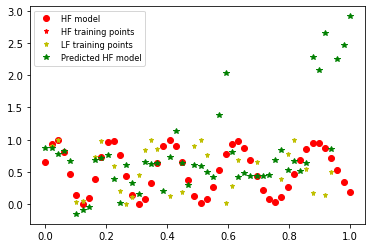

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.016105958770403626
R^2: 0.870542909848361
2/2 [==============================] - 0s 3ms/step
Elapsed time:  55.58813059999375
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.1263743685719162
R^2: -0.11639331062286984

HF Model:
Test MSE: 0.12142713018756489
R^2: -0.07268932301241171
2/2 [==============================] - 0s 0s/step


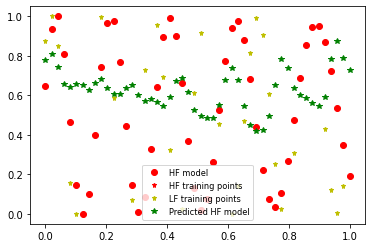

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 16ms/step

LF Model:
Test MSE: 0.06152687138811902
R^2: 0.5177152941367797
2/2 [==============================] - 0s 0s/step
Elapsed time:  57.76327229998424
2/2 [==============================] - 0s 17ms/step

Lin Model:
Test MSE: 0.11407093933479619
R^2: -0.0077046085287728605

HF Model:
Test MSE: 0.10896416309228917
R^2: 0.03740873922052379
2/2 [==============================] - 0s 1ms/step


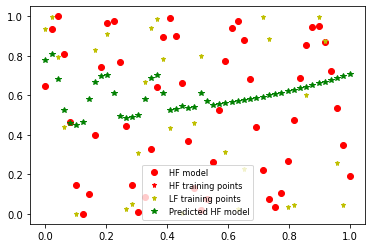

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 17ms/step

LF Model:
Test MSE: 0.12592329251820156
R^2: -0.03646187801349621
2/2 [==============================] - 0s 3ms/step
Elapsed time:  56.850941899989266
2/2 [==============================] - 0s 4ms/step

Lin Model:
Test MSE: 0.11991599073101751
R^2: -0.05933989147995877

HF Model:
Test MSE: 0.11984909069378849
R^2: -0.05874889541891504
2/2 [==============================] - 0s 6ms/step


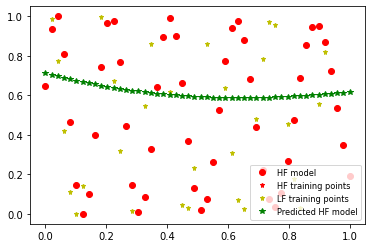

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.10329457449214403
R^2: 0.1711929591254141
2/2 [==============================] - 0s 3ms/step
Elapsed time:  62.56474829997751
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.099902921321276
R^2: 0.11745590237084991

HF Model:
Test MSE: 0.10266593319284098
R^2: 0.09304740873844575
2/2 [==============================] - 0s 3ms/step


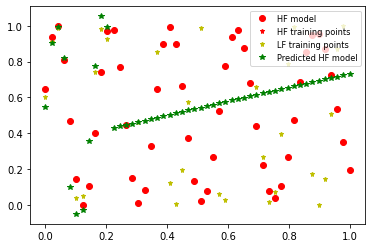

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 1ms/step

LF Model:
Test MSE: 0.11407496983909735
R^2: -0.007218112977677604
2/2 [==============================] - 0s 0s/step
Elapsed time:  53.77438980000443
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.11989865762952918
R^2: -0.059186770568079305

HF Model:
Test MSE: 0.11968287986226528
R^2: -0.057280586120419974
2/2 [==============================] - 0s 4ms/step


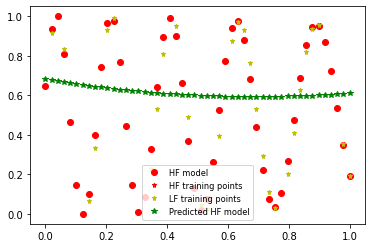

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 0s/step

LF Model:
Test MSE: 0.1175993762053566
R^2: -0.00019304311882151204
2/2 [==============================] - 0s 3ms/step
Elapsed time:  53.2054542999831
2/2 [==============================] - 0s 16ms/step

Lin Model:
Test MSE: 0.11992956380683237
R^2: -0.05945979626140718

HF Model:
Test MSE: 0.1230505538054087
R^2: -0.0870306747259646
2/2 [==============================] - 0s 16ms/step


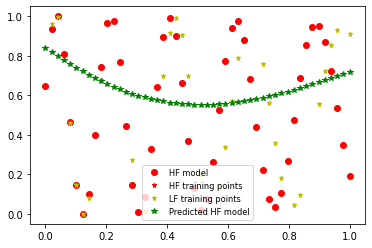

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 2ms/step

LF Model:
Test MSE: 6.765439397030056e-05
R^2: 0.9994278511174097
2/2 [==============================] - 0s 0s/step
Elapsed time:  55.93283279999741
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.08063468582170216
R^2: 0.287671820854265

HF Model:
Test MSE: 0.059508236098985264
R^2: 0.4743032352318547
2/2 [==============================] - 0s 6ms/step


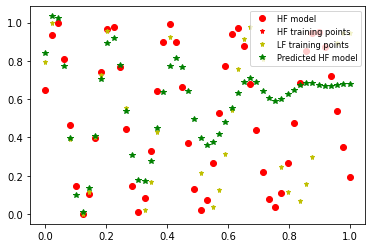

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.09233082482771435
R^2: 0.2588761223522337
2/2 [==============================] - 0s 27ms/step
Elapsed time:  60.645703400019556
2/2 [==============================] - 0s 3ms/step

Lin Model:
Test MSE: 0.11616794550561316
R^2: -0.026229596529822263

HF Model:
Test MSE: 0.11566878306794201
R^2: -0.021819987108010253
2/2 [==============================] - 0s 0s/step


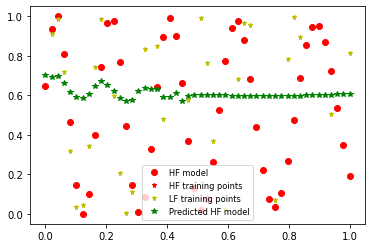

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.004501217206592935
R^2: 0.9604329024571474
2/2 [==============================] - 0s 16ms/step
Elapsed time:  56.082529199979035
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.0269186557400691
R^2: 0.7622001396424671

HF Model:
Test MSE: 0.02726039310338423
R^2: 0.7591812259916519
2/2 [==============================] - 0s 2ms/step


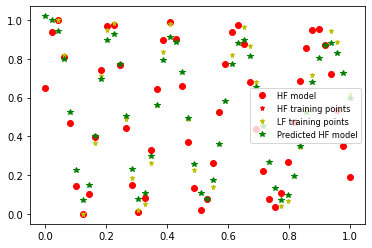

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
LF NN done
2/2 [==============================] - 0s 3ms/step

LF Model:
Test MSE: 0.003945905260967639
R^2: 0.9664999957026805
2/2 [==============================] - 0s 3ms/step
Elapsed time:  56.52656620001653
2/2 [==============================] - 0s 2ms/step

Lin Model:
Test MSE: 0.018253493639056605
R^2: 0.8387483282850723

HF Model:
Test MSE: 0.018327952045331677
R^2: 0.838090561463964
2/2 [==============================] - 0s 3ms/step


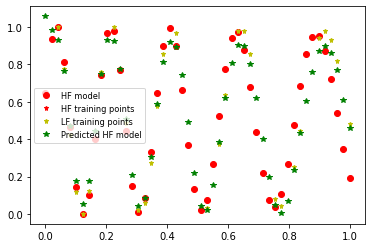

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
LF NN done
2/2 [==============================] - 0s 4ms/step

LF Model:
Test MSE: 0.00010375743291384075
R^2: 0.9991036457780177
2/2 [==============================] - 0s 0s/step
Elapsed time:  67.67709199999808
2/2 [==============================] - 0s 0s/step

Lin Model:
Test MSE: 0.01410077410324952
R^2: 0.8754335229416904

HF Model:
Test MSE: 0.014302485754401654
R^2: 0.8736515988018061
2/2 [==============================] - 0s 18ms/step


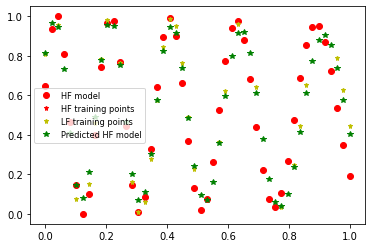

        10      28       46
0 -0.05875  0.4743  0.87365
        10       28      46
0  0.11985  0.05951  0.0143


In [ ]:
checkpoint = ModelCheckpoint("best_model_3NN.h5", monitor="val_loss", save_best_only=True)

for m in range(len(Discretizations)):
    for d in range(len(diffusion)):    # Loop over the range of the number of basis functions
        file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
        (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
        
        reaction_max = np.max(reaction_LF_test)
        reaction_min = np.min(reaction_LF_test)
        reaction_LF_test = (reaction_LF_test - reaction_min) / (
            reaction_max - reaction_min
        )
        
        permutation = np.random.permutation(len(reaction_LF_test))
        reaction_LF = reaction_LF_test[permutation][0:Nlf]
        U_LF_test = U_LF_test[
        :,
        - 1,
        int(4*(Discretizations[m]-1)/9),
        int(4*(Discretizations[m]-1)/9)
        ]
        U_t_max_test = np.max(U_LF_test)
        U_t_min_test = np.min(U_LF_test)
        
        U_LF_test = (U_LF_test - U_t_min_test) / (U_t_max_test - U_t_min_test)
       

        U_train_LF = U_LF_test[permutation][0:Nlf]


        print(
        f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
        )
        
        print(
        f"********************  # Diff: = {diffusion[d]}  ********************"
        )

        test_mse_HF_list = []
        test_mse_LF_list = []
        test_mse_Lin_list = []

        r2_HF_list = []
        r2_LF_list = []
        r2_Lin_list = []
 

       ##########################       FIRST NN: NN_LF     ##########################
        K.clear_session()
        bestLF_params = {
            "lr": 0.0255,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
        }

        modelLF = getModel(bestLF_params, "LF")

        histLF = modelLF.fit(
            reaction_LF, U_train_LF, epochs=NepoLF, batch_size=Nlf, verbose=0
        )
        print("LF NN done")

        ULF = modelLF.predict(reaction_LF_test)
        U_LF_list.append(ULF)
        print("\nLF Model:")

        test_mse = np.mean(np.square(U_LF_test - ULF[:, 0]))
        test_mse_LF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r_2 = 1 - np.sum(np.square(U_LF_test - ULF[:, 0])) / np.sum(
            np.square(U_LF_test - np.mean(U_LF_test))
        )
        r2_LF_list.append(r_2)
        print(f"R^2: {r_2}")

        start = perf_counter()
        ##########################    SECOND NN: NN_Lin    ##########################
        reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
        reaction_test_in = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help)
        ).transpose()  # <- TEST INPUT for the second NN: NN_Lin

        reaction_train_help = modelLF.predict(reaction_HF)[
            :, 0
        ]  # f_LF(mu_hf_train)
        reaction_lin = np.vstack(
            (reaction_HF[:, 0], reaction_train_help)
        ).transpose()  # <- TRAINING INPUT for the second NN: NN_Lin

        bestLin_params = {
            "lr": 0.001,
            "kernel_init": "glorot_uniform",
            "opt": "Adam",
            "l2weight": 0.01,
        }
        modelLin = getModel(bestLin_params, "Hflin")
        histLin = modelLin.fit(
            reaction_lin,
            U_HF,
            validation_data=(reaction_test_in, U_HF_test),
            epochs=NepoLin,
            batch_size=n_HF,
            verbose=0,
            validation_freq=50,
        )

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )

        ##########################    THIRD NN: NN_HF    ##########################
        # Input for training NN_HF
        reaction_help1 = modelLin.predict(reaction_lin)[:, 0]
        reaction_final = np.vstack(
            (reaction_HF[:, 0], reaction_train_help, reaction_help1)
        ).transpose()

        # Input for testing NN_HF
        reaction_test_help1 = modelLin.predict(reaction_test_in)[:, 0]
        reaction_test_final = np.vstack(
            (reaction_HF_test[:, 0], reaction_test_help, reaction_test_help1)
        ).transpose()

        name = "3step"
        MAX_EVAL = 15

        K.clear_session()
        # best paramters obtained by HPO:
        best_params = {
            "kernel_init": "glorot_uniform",
            "l2weight": 0.0001738393292451542,
            "lr": 0.0003670853655509693,
            "nodes": 48.0,
            "opt": "Adam",
        }
        # best_params = {'kernel_init': 'glorot_uniform', 'l2weight': 0.00015338174139229794, 'lr': 0.010752960934369659, 'nodes': 28.0, 'opt': 'Adam'}
        finalModel = getModel(
            best_params, name
        )  # final model chosen according to the best paramters
        hist = finalModel.fit(
            reaction_final,
            U_HF,
            validation_data=(reaction_test_final, U_HF_test),
            epochs=NepoHF,
            batch_size=n_HF,
            validation_freq=50,
            verbose=0,
            callbacks=[checkpoint]
        )

        UHF = finalModel.predict(reaction_test_final)
        U_HF_list.append(UHF)

        stop = perf_counter()
        elapsed = stop - start
        print("Elapsed time: ", elapsed)

        ULin = modelLin.predict(
            np.vstack((reaction_HF_test[:, 0], reaction_test_help)).transpose()
        )
        U_Lin_list.append(ULin)
        print("\nLin Model:")

        test_mse = np.mean(np.square(U_HF_test - ULin[:, 0]))
        test_mse_Lin_list.append(test_mse)
        print(f"Test MSE: {test_mse}")

        r2_Lin = 1 - np.sum(np.square(U_HF_test - ULin[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_Lin_list.append(r2_Lin)
        print(f"R^2: {r2_Lin}")

        print("\nHF Model:")
        test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
        test_mse_HF_list.append(test_mse)
        print(f"Test MSE: {test_mse}")
        r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
            np.square(U_HF_test - np.mean(U_HF_test))
        )
        r2_HF_list.append(r2_HF)
        print(f"R^2: {r2_HF}")

        plt.figure()
        plt.plot(
        reaction_test_in[:, 0], U_HF_test, "ro", linewidth=1.5, label="HF model"
        )
        plt.plot(
        reaction_final[:, 0],
        U_HF,
        "r*",
        markersize=5,
        label="HF training points",
        )
        plt.plot(
        reaction_LF,
        U_train_LF,
        "y*",
        markersize=5,
        label="LF training points",
        )
        plt.plot(
        reaction_test_in[:, 0],
        finalModel.predict(reaction_test_final),
        "g*",
        linewidth=3,
        label="Predicted HF model",
        )
        plt.legend(prop={"size": 8.3})
        plt.show()



        checkpoint = ModelCheckpoint("best_model.h5", monitor="val_loss", save_best_only=True)

        
        r2_LF_df[str(Discretizations[m])] = r2_LF_list
        r2_HF_df[str(Discretizations[m])] = r2_HF_list
        r2_Lin_df[str(Discretizations[m])] = r2_Lin_list
        mse_LF_df[str(Discretizations[m])] = test_mse_LF_list
        mse_HF_df[str(Discretizations[m])] = test_mse_HF_list
        mse_Lin_df[str(Discretizations[m])] = test_mse_Lin_list

print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

In [4]:
#########################     SAVE the OUTPUT      ##########################
os.makedirs("Output_3NN_per")

r2_HF_df.to_csv(
    "./Output_3NN_per/r2_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_HF_df.to_csv(
    "./Output_3NN_per/mse_HF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_LF_df.to_csv(
    "./Output_3NN_per/r2_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_LF_df.to_csv(
    "./Output_3NN_per/mse_LF_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
r2_Lin_df.to_csv(
    "./Output_3NN_per/r2_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)
mse_Lin_df.to_csv(
    "./Output_3NN_per/mse_Lin_lhs.txt", header=True, index=False, sep="\t", mode="a"
)

with open("estimated_UHF.txt", "w") as file:
    for item in UHF[:, 0]:
        file.write(f"{UHF}\n")

NameError: name 'r2_HF_df' is not defined